<a href="https://colab.research.google.com/github/codeyson/energy_demand_forecasting/blob/main/lstm_energy_forecasting_tuned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Extracting the Data

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = "/content/drive/MyDrive/TIP Files/32Sx/CPE 313 (Deep Learning with Python)/Demand Forecasting/"
file_path = os.path.join(data_path, "energy_dataset.csv")

energy_data = pd.read_csv(file_path)
energy_data.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [3]:
energy_data.shape

(35064, 29)

In [4]:
energy_data.columns

Index(['time', 'generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil coal-derived gas', 'generation fossil gas',
       'generation fossil hard coal', 'generation fossil oil',
       'generation fossil oil shale', 'generation fossil peat',
       'generation geothermal', 'generation hydro pumped storage aggregated',
       'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation marine',
       'generation nuclear', 'generation other', 'generation other renewable',
       'generation solar', 'generation waste', 'generation wind offshore',
       'generation wind onshore', 'forecast solar day ahead',
       'forecast wind offshore eday ahead', 'forecast wind onshore day ahead',
       'total load forecast', 'total load actual', 'price day ahead',
       'price actual'],
      dtype='object')

# Data Visualization

## Monthly

In [5]:
vis_df = energy_data.copy()
vis_df['time'] = pd.to_datetime(vis_df['time'], utc=True)
vis_df_monthly = vis_df.set_index('time').resample('ME').mean(numeric_only=True).reset_index()
vis_df_monthly.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 00:00:00+00:00,447.000000,329.000000,0.0,4844.000000,4821.000000,162.000000,0.0,0.0,0.0,...,196.000000,0.0,6378.000000,17.000000,NaN,6436.000000,26118.000000,25385.000000,50.100000,65.410000
1,2015-01-31 00:00:00+00:00,483.716235,572.843111,0.0,4849.984993,5411.347885,306.030014,0.0,0.0,0.0,...,228.884038,0.0,7583.579809,1122.850806,NaN,7589.591398,30117.932796,29997.428765,47.419395,64.898763
2,2015-02-28 00:00:00+00:00,470.226190,313.416667,0.0,4675.349702,4047.590774,319.404762,0.0,0.0,0.0,...,213.821429,0.0,7729.565476,1207.175595,NaN,7721.244048,29618.687500,29478.727685,44.206295,56.412991
3,2015-03-31 00:00:00+00:00,468.071237,244.405914,0.0,4615.216398,4236.115591,319.208333,0.0,0.0,0.0,...,177.245968,0.0,6750.033602,1321.659946,NaN,6716.736559,28385.888441,28431.045699,46.556801,55.478562
4,2015-04-30 00:00:00+00:00,426.409471,463.247911,0.0,4952.200557,4819.632312,338.793872,0.0,0.0,0.0,...,192.327298,0.0,5496.034819,1449.394444,NaN,5482.701389,27453.072222,27438.268156,48.900778,58.402806


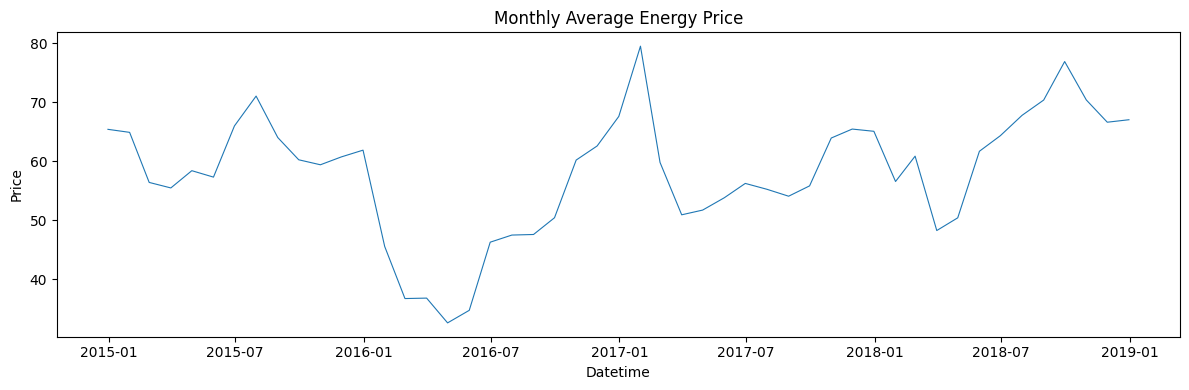

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(vis_df_monthly['time'], vis_df_monthly['price actual'], linewidth=0.8)
plt.title("Monthly Average Energy Price")
plt.xlabel("Datetime")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

## Daily

In [7]:
vis_df_daily = vis_df.set_index('time').resample('D').mean(numeric_only=True).reset_index()
vis_df_daily.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 00:00:00+00:00,447.000000,329.000000,0.0,4844.000000,4821.000000,162.000000,0.0,0.0,0.0,...,196.000000,0.0,6378.000000,17.000000,NaN,6436.000000,26118.000000,25385.000000,50.100000,65.410000
1,2015-01-01 00:00:00+00:00,425.208333,243.708333,0.0,4187.791667,4099.458333,161.500000,0.0,0.0,0.0,...,201.041667,0.0,3994.000000,1049.500000,NaN,3942.416667,24753.250000,23966.958333,45.031667,62.090833
2,2015-01-02 00:00:00+00:00,389.875000,0.000000,0.0,3566.166667,1258.125000,200.833333,0.0,0.0,0.0,...,186.583333,0.0,11060.041667,1187.208333,NaN,11117.041667,27519.416667,27188.541667,17.598333,69.443750
3,2015-01-03 00:00:00+00:00,436.875000,0.000000,0.0,3451.791667,1375.958333,229.791667,0.0,0.0,0.0,...,202.333333,0.0,9137.250000,1133.375000,NaN,9113.416667,25500.833333,25097.750000,25.342083,65.223333
4,2015-01-04 00:00:00+00:00,396.375000,13.583333,0.0,3526.125000,2315.291667,356.625000,0.0,0.0,0.0,...,159.125000,0.0,8016.125000,2292.041667,NaN,8022.833333,27167.875000,27104.916667,30.658333,58.912083


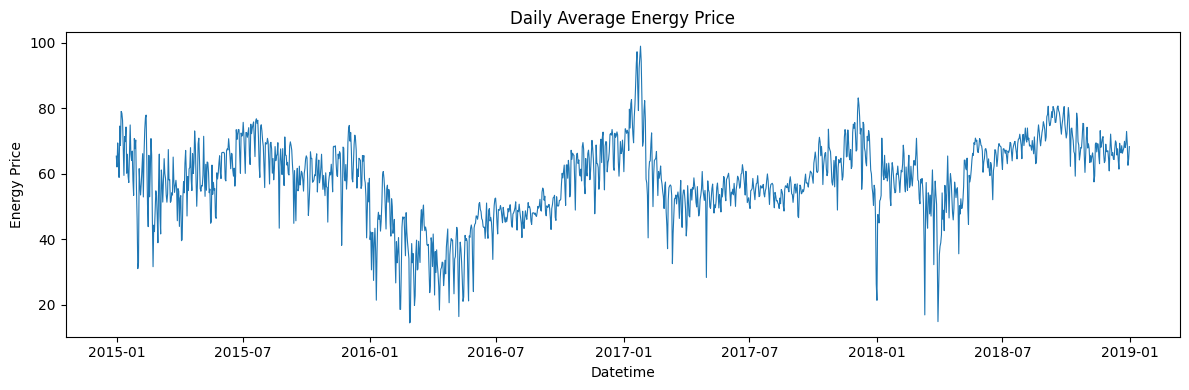

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(vis_df_daily['time'], vis_df_daily['price actual'], linewidth=0.8)
plt.title("Daily Average Energy Price")
plt.xlabel("Datetime")
plt.ylabel("Energy Price")
plt.tight_layout()
plt.show()

# Transforming the Data

In [9]:
energy_data = vis_df.copy()
energy_data['time'] = pd.to_datetime(energy_data['time'], utc=True)
energy_data = energy_data.set_index('time').resample('D').mean(numeric_only=True).reset_index()

energy_data.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 00:00:00+00:00,447.000000,329.000000,0.0,4844.000000,4821.000000,162.000000,0.0,0.0,0.0,...,196.000000,0.0,6378.000000,17.000000,NaN,6436.000000,26118.000000,25385.000000,50.100000,65.410000
1,2015-01-01 00:00:00+00:00,425.208333,243.708333,0.0,4187.791667,4099.458333,161.500000,0.0,0.0,0.0,...,201.041667,0.0,3994.000000,1049.500000,NaN,3942.416667,24753.250000,23966.958333,45.031667,62.090833
2,2015-01-02 00:00:00+00:00,389.875000,0.000000,0.0,3566.166667,1258.125000,200.833333,0.0,0.0,0.0,...,186.583333,0.0,11060.041667,1187.208333,NaN,11117.041667,27519.416667,27188.541667,17.598333,69.443750
3,2015-01-03 00:00:00+00:00,436.875000,0.000000,0.0,3451.791667,1375.958333,229.791667,0.0,0.0,0.0,...,202.333333,0.0,9137.250000,1133.375000,NaN,9113.416667,25500.833333,25097.750000,25.342083,65.223333
4,2015-01-04 00:00:00+00:00,396.375000,13.583333,0.0,3526.125000,2315.291667,356.625000,0.0,0.0,0.0,...,159.125000,0.0,8016.125000,2292.041667,NaN,8022.833333,27167.875000,27104.916667,30.658333,58.912083


## Checking for Null Values

In [10]:
print(energy_data['price actual'].isnull().sum())

0


In [11]:
print(f"Min price: {energy_data['price actual'].min()}")
print(f"Zeros: {(energy_data['price actual'] == 0).sum()}")
print(f"Negatives: {(energy_data['price actual'] < 0).sum()}")

Min price: 14.514583333333334
Zeros: 0
Negatives: 0


In [12]:
energy_data = energy_data[['time', 'price actual']].copy()
energy_data['price actual'] = energy_data['price actual'].interpolate(method='linear')
energy_data = energy_data.dropna().reset_index(drop=True)

energy_data.head()

,time,price actual
0,2014-12-31 00:00:00+00:00,65.410000
1,2015-01-01 00:00:00+00:00,62.090833
2,2015-01-02 00:00:00+00:00,69.443750
3,2015-01-03 00:00:00+00:00,65.223333
4,2015-01-04 00:00:00+00:00,58.912083


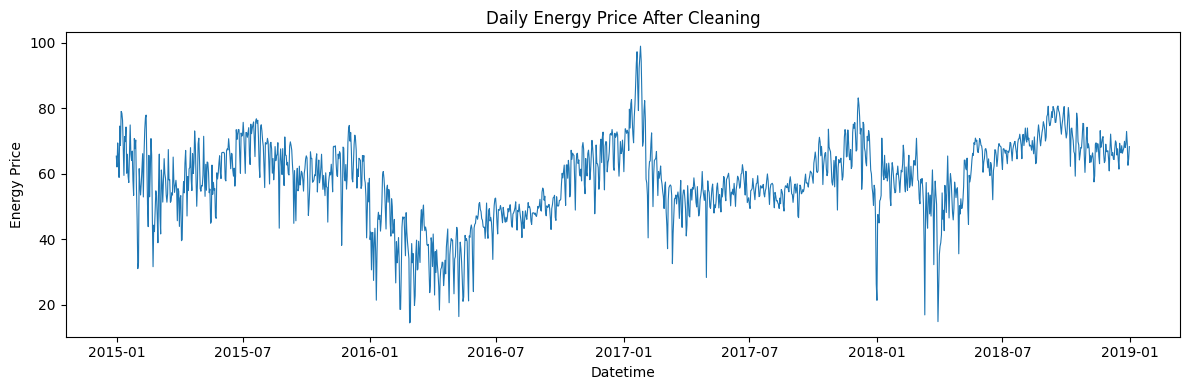

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(energy_data['time'], energy_data['price actual'], linewidth=0.8)
plt.title("Daily Energy Price After Cleaning")
plt.xlabel("Datetime")
plt.ylabel("Energy Price")
plt.tight_layout()
plt.show()

# LSTM

## Train - Validation - Test Split

In [14]:
# Chronological split: 70% train, 15% validation, 15% test
train_end = int(len(energy_data) * 0.70)
val_end = int(len(energy_data) * 0.85)

train_df = energy_data.iloc[:train_end].copy()
val_df = energy_data.iloc[train_end:val_end].copy()
test_df = energy_data.iloc[val_end:].copy()

print(f"Total observations: {len(energy_data)}")
print(f"Train size: {len(train_df)} ({len(train_df)/len(energy_data)*100:.2f}%)")
print(f"Validation size: {len(val_df)} ({len(val_df)/len(energy_data)*100:.2f}%)")
print(f"Test size: {len(test_df)} ({len(test_df)/len(energy_data)*100:.2f}%)")

print(f"Train period: {train_df['time'].iloc[0]} -> {train_df['time'].iloc[-1]}")
print(f"Validation period: {val_df['time'].iloc[0]} -> {val_df['time'].iloc[-1]}")
print(f"Test period: {test_df['time'].iloc[0]} -> {test_df['time'].iloc[-1]}")

Total observations: 1462
Train size: 1023 (69.97%)
Validation size: 219 (14.98%)
Test size: 220 (15.05%)
Train period: 2014-12-31 00:00:00+00:00 -> 2017-10-18 00:00:00+00:00
Validation period: 2017-10-19 00:00:00+00:00 -> 2018-05-25 00:00:00+00:00
Test period: 2018-05-26 00:00:00+00:00 -> 2018-12-31 00:00:00+00:00


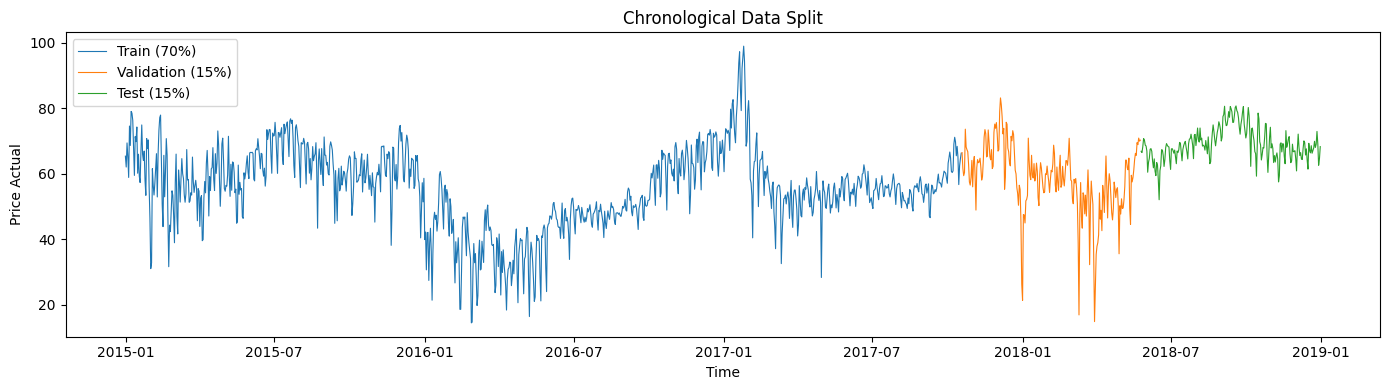

In [15]:
plt.figure(figsize=(14, 4))
plt.plot(train_df['time'], train_df['price actual'], label='Train (70%)', linewidth=0.8)
plt.plot(val_df['time'], val_df['price actual'], label='Validation (15%)', linewidth=0.8)
plt.plot(test_df['time'], test_df['price actual'], label='Test (15%)', linewidth=0.8)
plt.title("Chronological Data Split")
plt.xlabel("Time")
plt.ylabel("Price Actual")
plt.legend()
plt.tight_layout()
plt.show()

## Scaling and Sequence Preparation

In [16]:
from sklearn.preprocessing import MinMaxScaler

lookback = 30

scaler = MinMaxScaler()

train_values = train_df[['price actual']].values
val_values = val_df[['price actual']].values
test_values = test_df[['price actual']].values

scaled_train = scaler.fit_transform(train_values)
scaled_val = scaler.transform(val_values)
scaled_test = scaler.transform(test_values)

print("Scaled train shape:", scaled_train.shape)
print("Scaled validation shape:", scaled_val.shape)
print("Scaled test shape:", scaled_test.shape)

Scaled train shape: (1023, 1)
Scaled validation shape: (219, 1)
Scaled test shape: (220, 1)


In [17]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Train sequences
X_train, y_train = create_sequences(scaled_train, lookback)

# Validation sequences use the tail of train for the first lookback window
val_combined = np.vstack([scaled_train[-lookback:], scaled_val])
X_val, y_val = create_sequences(val_combined, lookback)

# Test sequences use the tail of validation for the first lookback window
test_combined = np.vstack([scaled_val[-lookback:], scaled_test])
X_test, y_test = create_sequences(test_combined, lookback)

# Reshape for LSTM: [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (993, 30, 1)
y_train shape: (993,)
X_val shape: (219, 30, 1)
y_val shape: (219,)
X_test shape: (220, 30, 1)
y_test shape: (220,)


# Hyperparameter Tuning

In [18]:
import sys
import subprocess

# Install keras-tuner if needed
try:
    import keras_tuner as kt
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "keras-tuner", "-q"])
    import keras_tuner as kt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(lookback, 1)))

    units_1 = hp.Choice("units_1", [32, 64, 128])
    units_2 = hp.Choice("units_2", [16, 32, 64])
    dropout_1 = hp.Choice("dropout_1", [0.0, 0.2, 0.3])
    dropout_2 = hp.Choice("dropout_2", [0.0, 0.2, 0.3])
    dense_units = hp.Choice("dense_units", [8, 16, 32])
    learning_rate = hp.Choice("learning_rate", [1e-3, 5e-4, 1e-4])

    model.add(LSTM(units_1, return_sequences=True))
    model.add(Dropout(dropout_1))
    model.add(LSTM(units_2))
    model.add(Dropout(dropout_2))
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_loss',
    max_trials=10,
    overwrite=True,
    directory='lstm_tuning',
    project_name='energy_forecast'
)

tuner.search_space_summary()

Search space summary
Default search space size: 6
units_1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
units_2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dropout_1 (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.2, 0.3], 'ordered': True}
dropout_2 (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.2, 0.3], 'ordered': True}
dense_units (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


In [19]:
tuning_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=tuning_callbacks,
    verbose=1
)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
for key, value in best_hp.values.items():
    print(f"  {key}: {value}")

best_model = tuner.hypermodel.build(best_hp)
best_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_tuned_lstm_model.keras', monitor='val_loss', save_best_only=True)
]

history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Trial 10 Complete [00h 00m 30s]
val_loss: 0.012302122078835964

Best val_loss So Far: 0.009907671250402927
Total elapsed time: 00h 04m 51s
Best hyperparameters:
  units_1: 32
  units_2: 64
  dropout_1: 0.0
  dropout_2: 0.3
  dense_units: 32
  learning_rate: 0.001


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,297 (122.25 KB)

 Trainable params: 31,297 (122.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0344 - mae: 0.1384 - val_loss: 0.0110 - val_mae: 0.0770
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0108 - mae: 0.0796 - val_loss: 0.0107 - val_mae: 0.0753
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0115 - mae: 0.0825 - val_loss: 0.0113 - val_mae: 0.0798
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0109 - mae: 0.0800 - val_loss: 0.0113 - val_mae: 0.0802
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0107 - mae: 0.0793 - val_loss: 0.0120 - val_mae: 0.0846
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0103 - mae: 0.0762 - val_loss: 0.0113 - val_mae: 0.0807
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0087 - mae: 0.0697 - val_loss: 0.0105 - val_mae: 0.0758
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0087 - mae: 0.0700 - val_loss: 0.0104 - val_mae: 0.0715
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.009

# Save the Tuned Model

In [20]:
best_model.save("tuned_lstm_energy_model.keras")
print("Saved model as tuned_lstm_energy_model.keras")

Saved model as tuned_lstm_energy_model.keras


In [21]:
loaded_lstm_model = tf.keras.models.load_model("tuned_lstm_energy_model.keras")
print("Loaded saved tuned LSTM model successfully.")

Loaded saved tuned LSTM model successfully.


## Forecasting

In [22]:
scaled_preds = loaded_lstm_model.predict(X_test)
lstm_preds = scaler.inverse_transform(scaled_preds).flatten()
actuals = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

pred_df = pd.DataFrame({
    'time': test_df['time'].values,
    'actual': actuals,
    'predicted': lstm_preds
})

pred_df.head()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step


,time,actual,predicted
0,2018-05-26,66.902083,66.478081
1,2018-05-27,66.510833,66.198318
2,2018-05-28,68.266250,65.761482
3,2018-05-29,70.764167,65.758064
4,2018-05-30,70.332917,66.360725


## Metrics and Visualization

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(pred_df['actual'], pred_df['predicted'])
mse = mean_squared_error(pred_df['actual'], pred_df['predicted'])
rmse = np.sqrt(mse)
mape = np.mean(
    np.abs((pred_df['actual'] - pred_df['predicted']) / pred_df['actual'])
) * 100

metrics_df = pd.DataFrame([{
    'Model': 'LSTM',
    'MAE': round(mae, 2),
    'MSE': round(mse, 2),
    'RMSE': round(rmse, 2),
    'MAPE(%)': round(mape, 2)
}])

metrics_df

,Model,MAE,MSE,RMSE,MAPE(%)
0,LSTM,3.21,15.88,3.99,4.62


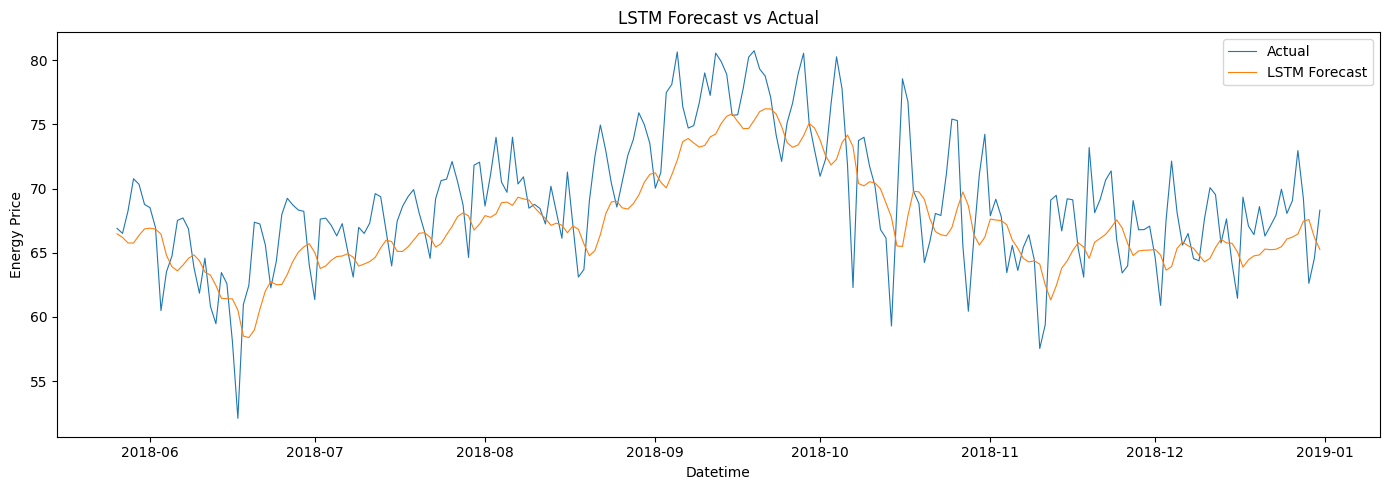

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(pred_df['time'], pred_df['actual'], label='Actual', linewidth=0.8)
plt.plot(pred_df['time'], pred_df['predicted'], label='LSTM Forecast', linewidth=0.8)
plt.title("LSTM Forecast vs Actual")
plt.xlabel("Datetime")
plt.ylabel("Energy Price")
plt.legend()
plt.tight_layout()
plt.show()

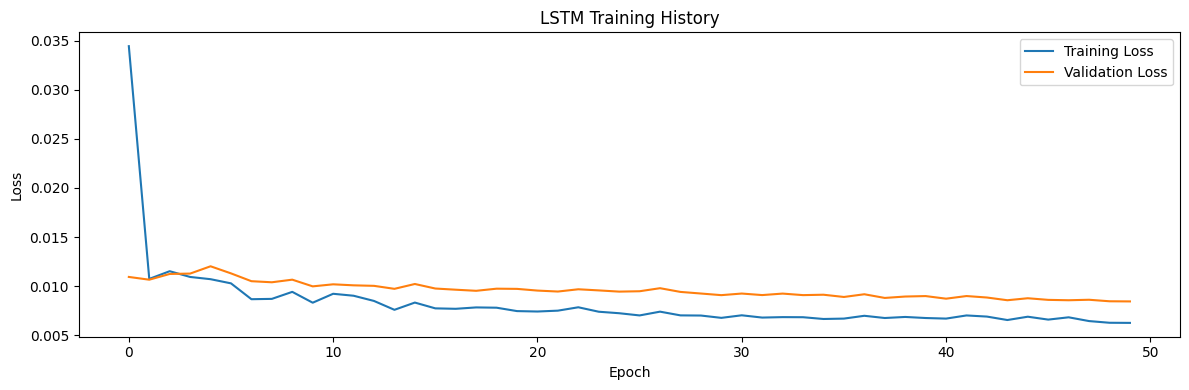

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()